# Raw Sampling-Step Sweep

Evaluate raw VP-SDE U-Net and VE-SDE NCSN++ checkpoints on CIFAR-10 birds across sampling-step counts.


In [1]:
import copy
import json
import math
import os
import random
import subprocess
import sys
import time
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid
from tqdm.auto import tqdm


## Google Drive


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## Configuration

Sweep:

$$100,200,300,\ldots,1000$$

FID gap:

$$\mathrm{fid\_gap}=\mathrm{fid\_test}-\mathrm{fid\_train}$$

NN gap:

$$\mathrm{nn\_gap\_mean\_mse}=\mathrm{test\_nn\_mean\_mse}-\mathrm{train\_nn\_mean\_mse}$$


In [3]:
# Configuration

PROJECT_DIR = "/content/drive/MyDrive/DD2424/Project/working_nets"

VP_UNET_CHECKPOINT = os.path.join(PROJECT_DIR, "bird_vp_sde_checkpoint_1760_epochs.pth")

# Raw/non-EMA VE checkpoint. Change only this filename if your raw checkpoint
# is stored under another name.
VE_NCSNPP_CHECKPOINT = os.path.join(PROJECT_DIR, 'bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth')

OUTPUT_DIR = os.path.join(PROJECT_DIR, "bird_vp_ve_raw_sampling_step_gap_analysis")

STEPS_LIST = list(range(100, 1001, 100))
NUM_FID_SAMPLES_PER_SETTING = 5000
NUM_NN_SAMPLES_PER_SETTING = 1000
CORRECTOR_STEPS = 0

SAMPLE_BATCH_SIZE = 128
FID_BATCH_SIZE = 100
DATA_BATCH_SIZE = 128
NN_REF_BATCH_SIZE = 512
NN_QUERY_BATCH_SIZE = 100

SAMPLE_EPS = 1e-3
SAMPLE_SNR = 0.01

FID_FEATURE = 2048

# None means use all bird images in each split: train=5000, test=1000.
FID_REAL_MAX_TRAIN = None
FID_REAL_MAX_TEST = None
NN_REFERENCE_MAX_TRAIN = 1000
NN_REFERENCE_MAX_TEST = 1000

# Raw/non-EMA weights only. No EMA keys are used or accepted.
VP_WEIGHT_KEY = "vp_net"
VE_WEIGHT_KEY = "ve_net"
VE_ALLOWED_RAW_WEIGHT_KEYS = ("ve_net", "ncsnpp", "model", "state_dict")
VP_ALLOWED_RAW_WEIGHT_KEYS = ("vp_net", "model", "state_dict")

BASE_SEED = 1234
SHOW_PROGRESS = True
SAVE_FID_SAMPLE_GRIDS = False
RESUME_IF_RESULTS_EXIST = True

RUN_IMAGE_EVOLUTION = True
EVOLUTION_NUM_IMAGES = 5
EVOLUTION_NUM_STEPS = 1000
EVOLUTION_CAPTURE_STEPS = list(range(100, 1001, 100))
EVOLUTION_SEED_OFFSET = 900_000

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = torch.cuda.is_available()

bar_b_min = 0.1
bar_b_max = 20.0

VE_SIGMA_MIN = 0.01
VE_SIGMA_MAX = 50.0

NCSNpp = None


## Setup and data

Mount Drive, install dependencies, load CIFAR-10 bird train/test images.


In [4]:
# Setup helpers

def maybe_mount_drive():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        print("Google Drive mount skipped. This is normal outside Colab.")


def run_pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


def install_dependencies_if_needed():
    missing = []

    try:
        import ml_collections # noqa: F401
    except Exception:
        missing.append("ml-collections")

    try:
        import ninja # noqa: F401
    except Exception:
        missing.append("ninja")

    try:
        from torchmetrics.image.fid import FrechetInceptionDistance # noqa: F401
    except Exception:
        missing.extend(["torchmetrics", "torch-fidelity"])

    if missing:
        print("Installing missing packages:", missing)
        run_pip_install(missing)


def ensure_score_sde_repo():
    repo_path = os.path.join(PROJECT_DIR, "score_sde_pytorch")

    if not os.path.exists(repo_path):
        print("Cloning score_sde_pytorch into:", repo_path)
        subprocess.check_call(['git', 'clone', 'https://github.com/yang-song/score_sde_pytorch.git', repo_path])

    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    global NCSNpp
    from models.ncsnpp import NCSNpp as ImportedNCSNpp
    NCSNpp = ImportedNCSNpp


def torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_json_safe(rows):
    safe_rows = []
    for row in rows:
        safe_row = {}
        for key, value in row.items():
            if isinstance(value, (np.integer, )):
                safe_row[key] = int(value)
            elif isinstance(value, (np.floating, )):
                safe_row[key] = float(value)
            else:
                safe_row[key] = value
                safe_rows.append(safe_row)
                return safe_rows

# CIFAR-10 bird data

def build_cifar10_bird_loaders():
    transform_plain = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_plain)

    target_idx = train_full.classes.index("bird")
    train_indices = [i for i, label in enumerate(train_full.targets) if label == target_idx]
    train_set = Subset(train_full, train_indices)

    test_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_plain)

    test_indices = [i for i, label in enumerate(test_full.targets) if label == target_idx]
    test_set = Subset(test_full, test_indices)

    train_loader = DataLoader(train_set, batch_size=DATA_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    test_loader = DataLoader(test_set, batch_size=DATA_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    print("CIFAR-10 target class: bird")
    print("Bird train images:", len(train_set))
    print("Bird test images:", len(test_set))

    return train_loader, test_loader


@torch.no_grad()
def collect_images_from_loader(loader, max_images=None):
    images_all = []
    total = 0

    for images, _ in loader:
        images_all.append(images.cpu())
        total += images.shape[0]
        if max_images is not None and total >= max_images:
            break

    images_all = torch.cat(images_all, dim=0)
    return images_all[:max_images] if max_images is not None else images_all


## VP-SDE U-Net

Raw checkpoint state: `vp_net`.


In [5]:
# VP-SDE U-Net architecture

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim=dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        batch, channels, height, width = x.shape
        h = self.norm(x)

        q = self.q(h).reshape(batch, channels, height * width).permute(0, 2, 1)
        k = self.k(h).reshape(batch, channels, height * width)
        v = self.v(h).reshape(batch, channels, height * width)

        attn = torch.softmax(q @ k / math.sqrt(channels), dim=-1)
        out = (v @ attn.permute(0, 2, 1)).reshape(batch, channels, height, width)

        return x + self.proj(out)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)
        self.act = nn.SiLU()

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))

        scale, shift = self.emb_proj(emb).chunk(2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = self.conv2(self.act(h))

        return h + self.skip(x)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.ConvTranspose2d(ch, ch, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, img_ch=3, base_ch=128):
        super().__init__()

        emb_dim = base_ch * 4

        self.time_emb = SinusoidalTimeEmbedding(emb_dim)

        self.emb_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))

        self.conv_in = nn.Conv2d(img_ch, base_ch, 3, padding=1)

        self.down1 = ResBlock(base_ch, 128, emb_dim)
        self.ds0 = Downsample(128)

        self.down2 = ResBlock(128, 256, emb_dim)
        self.ds1 = Downsample(256)

        self.down3 = ResBlock(256, 512, emb_dim)
        self.attn16 = SelfAttention(512)
        self.ds2 = Downsample(512)

        self.down4 = ResBlock(512, 512, emb_dim)
        self.attn8 = SelfAttention(512)

        self.mid1 = ResBlock(512, 512, emb_dim)
        self.mid_attn = SelfAttention(512)
        self.mid2 = ResBlock(512, 512, emb_dim)

        self.up4 = ResBlock(1024, 512, emb_dim)
        self.attn8_up = SelfAttention(512)
        self.us2 = Upsample(512)

        self.up3 = ResBlock(1024, 512, emb_dim)
        self.attn16_up = SelfAttention(512)
        self.us1 = Upsample(512)

        self.up2 = ResBlock(768, 256, emb_dim)
        self.us0 = Upsample(256)

        self.up1 = ResBlock(384, 128, emb_dim)

        self.conv_out = nn.Conv2d(128, img_ch, 3, padding=1)

    def forward(self, x, t):
        emb = self.emb_mlp(self.time_emb(t * 999.0))

        x = self.conv_in(x)

        d1 = self.down1(x, emb)
        d1_down = self.ds0(d1)

        d2 = self.down2(d1_down, emb)
        d2_down = self.ds1(d2)

        d3 = self.down3(d2_down, emb)
        d3 = self.attn16(d3)
        d3_down = self.ds2(d3)

        d4 = self.down4(d3_down, emb)
        d4 = self.attn8(d4)

        mid = self.mid1(d4, emb)
        mid = self.mid_attn(mid)
        mid = self.mid2(mid, emb)

        u4 = self.up4(torch.cat([mid, d4], dim=1), emb)
        u4 = self.attn8_up(u4)
        u4_up = self.us2(u4)

        u3 = self.up3(torch.cat([u4_up, d3], dim=1), emb)
        u3 = self.attn16_up(u3)
        u3_up = self.us1(u3)

        u2 = self.up2(torch.cat([u3_up, d2], dim=1), emb)
        u2_up = self.us0(u2)

        u1 = self.up1(torch.cat([u2_up, d1], dim=1), emb)

        return self.conv_out(u1)


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    batch = x.shape[0]
    batch_t = torch.ones(batch, device=x.device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)

        score_norm = torch.norm(score.reshape(batch, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(batch, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    batch = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(batch, device=x.device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score

    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_vp_sde_unet(net, num_samples, num_steps, img_shape=(3, 32, 32), eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=CORRECTOR_STEPS, denoise=True):
    net.eval()

    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps + 1, device=device)
    x_mean = x

    iterator = tqdm(range(num_steps), desc=f"VP sampler, {num_steps} steps", leave=False, disable=not SHOW_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x=x, t=t, net=net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 1
        x, x_mean = euler_maruyama_predictor_vp(x=x, t=t, t_next=t_next, net=net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


@torch.no_grad()
def sample_vp_sde_unet_evolution(net, num_images=EVOLUTION_NUM_IMAGES, num_steps=EVOLUTION_NUM_STEPS,
    capture_steps=EVOLUTION_CAPTURE_STEPS, img_shape=(3, 32, 32), eps=SAMPLE_EPS, snr=SAMPLE_SNR,
    corrector_steps=CORRECTOR_STEPS, denoise=True):
    net.eval()

    capture_set = set(int(step) for step in capture_steps)
    snapshots = {}

    x = torch.randn(num_images, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps + 1, device=device)
    x_mean = x

    iterator = tqdm(range(num_steps), desc=f"VP evolution, {num_steps} steps", leave=False, disable=not SHOW_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x=x, t=t, net=net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 1
        x, x_mean = euler_maruyama_predictor_vp(x=x, t=t, t_next=t_next, net=net, add_noise=add_noise)

        step_number = i + 1
        if step_number in capture_set:
            snapshots[step_number] = (x_mean if denoise else x).clamp(-1, 1).detach().cpu()

    return snapshots


## VE-SDE NCSN++

Raw checkpoint state: `ve_net` or `ncsnpp`.


In [6]:
# VE-SDE NCSN++ architecture wrapper

def sigma_t(t, sigma_min=VE_SIGMA_MIN, sigma_max=VE_SIGMA_MAX):
    return sigma_min * (sigma_max / sigma_min) ** t


def create_ncsnpp_ve_config(image_size=32, image_channels=3):
    config = SimpleNamespace()
    config.data = SimpleNamespace()
    config.data.image_size = image_size
    config.data.num_channels = image_channels
    config.data.centered = True

    config.training = SimpleNamespace()
    config.training.sde = "vesde"
    config.training.continuous = True

    config.model=SimpleNamespace()
    config.model.name = "ncsnpp"
    config.model.sigma_min = VE_SIGMA_MIN
    config.model.sigma_max = VE_SIGMA_MAX
    config.model.num_scales = 1000
    config.model.scale_by_sigma = True
    config.model.ema_rate = 0.999
    config.model.normalization = "GroupNorm"
    config.model.nonlinearity = "swish"
    config.model.nf = 128
    config.model.ch_mult = (1, 2, 2, 2)
    config.model.num_res_blocks = 4
    config.model.attn_resolutions = (16,)
    config.model.dropout = 0.1
    config.model.resamp_with_conv = True
    config.model.conditional = True
    config.model.fir = True
    config.model.fir_kernel = [1, 3, 3, 1]
    config.model.skip_rescale = True
    config.model.resblock_type = "biggan"
    config.model.progressive = "none"
    config.model.progressive_input = "residual"
    config.model.progressive_combine = "sum"
    config.model.attention_type = "ddpm"
    config.model.init_scale = 0.0
    config.model.embedding_type = "fourier"
    config.model.fourier_scale = 16
    config.model.conv_size = 3
    return config


class NCSNppVEScoreWrapper(nn.Module):
    def __init__(self, official_model):
        super().__init__()
        self.official_model = official_model

    def forward(self, images, continuous_timesteps):
        sigmas = sigma_t(continuous_timesteps)
        return self.official_model(images, sigmas)


@torch.no_grad()
def langevin_corrector_ve(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    batch = x.shape[0]
    batch_t = torch.ones(batch, device=x.device) * t

    for _ in range(n_steps):
        noise = torch.randn_like(x)
        score = net(x, batch_t)
        score_norm = torch.norm(score.reshape(batch, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(batch, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2
        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


def g_squared_t(batch_t, sigma_min=VE_SIGMA_MIN, sigma_max=VE_SIGMA_MAX):
    sig_t = sigma_t(batch_t, sigma_min, sigma_max)
    return 2.0 * (sig_t ** 2) * math.log(sigma_max / sigma_min)


@torch.no_grad()
def euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=True):
    batch = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(batch, device=x.device) * t
    g_squared = g_squared_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = g_squared * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(g_squared * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_ve_sde_ncsnpp(net, num_samples, num_steps, img_shape=(3, 32, 32), eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=CORRECTOR_STEPS, denoise=True, sigma_max=VE_SIGMA_MAX):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device) * sigma_max
    timesteps = torch.linspace(1.0, eps, num_steps + 1, device=device)
    x_mean = x
    iterator = tqdm(range(num_steps), desc=f"VE sampler, {num_steps} steps", leave=False, disable=not SHOW_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]
        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)
        add_noise = i < num_steps - 1
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


@torch.no_grad()
def sample_ve_sde_ncsnpp_evolution(net, num_images=EVOLUTION_NUM_IMAGES, num_steps=EVOLUTION_NUM_STEPS, capture_steps=EVOLUTION_CAPTURE_STEPS, img_shape=(3, 32, 32), eps=SAMPLE_EPS, snr=SAMPLE_SNR, corrector_steps=CORRECTOR_STEPS, denoise=True, sigma_max=VE_SIGMA_MAX):
    net.eval()
    capture_set = set(int(step) for step in capture_steps)
    snapshots = {}
    x = torch.randn(num_images, *img_shape, device=device) * sigma_max
    timesteps = torch.linspace(1.0, eps, num_steps + 1, device=device)
    x_mean = x
    iterator = tqdm(range(num_steps), desc=f"VE evolution, {num_steps} steps", leave=False, disable=not SHOW_PROGRESS)

    for i in iterator:
        t = timesteps[i]
        t_next = timesteps[i + 1]
        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)
        add_noise = i < num_steps - 1
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

        step_number = i + 1
        if step_number in capture_set:
            snapshots[step_number] = (x_mean if denoise else x).clamp(-1, 1).detach().cpu()

    return snapshots


## Raw model loading

EMA keys are rejected.


In [7]:
# Model loading

def normalized_state_dict_candidates(state_dict):
    candidates = [state_dict]
    if all(key.startswith("module.") for key in state_dict.keys()):
        candidates.append({key[len("module."):]: value for key, value in state_dict.items()})
    if not any(key.startswith("official_model.") for key in state_dict.keys()):
        candidates.append({f"official_model.{key}": value for key, value in state_dict.items()})
    return candidates


def load_state_dict_flexibly(model, state_dict, model_label):
    last_error = None
    for candidate in normalized_state_dict_candidates(state_dict):
        try:
            model.load_state_dict(candidate, strict=True)
            return
        except RuntimeError as error:
            last_error = error

    raise RuntimeError(f"Could not load state dict for {model_label}.\n{last_error}")


def looks_like_state_dict(obj):
    return isinstance(obj, dict) and obj and all(torch.is_tensor(value) for value in obj.values())


def get_raw_state_dict(checkpoint, preferred_key, allowed_keys, model_label):
    if preferred_key == "ema_net" or "ema" in preferred_key.lower():
        raise ValueError(f"EMA key is not allowed for {model_label}: {preferred_key}")
    if preferred_key in checkpoint:
        return checkpoint[preferred_key], preferred_key

    for key in allowed_keys:
        if key == "ema_net" or "ema" in key.lower():
            continue
        if key in checkpoint:
            return checkpoint[key], key

    if looks_like_state_dict(checkpoint):
        return checkpoint, "top_level_state_dict"

    raise KeyError(f"Could not find a raw/non-EMA state dict for {model_label}. Allowed keys: {allowed_keys}. Found keys: {list(checkpoint.keys())}")


def load_vp_unet_model(checkpoint_path, weight_key=VP_WEIGHT_KEY):
    assert os.path.exists(checkpoint_path), f"Missing VP checkpoint: {checkpoint_path}"
    checkpoint = torch_load(checkpoint_path)
    model=UNet().to(device)
    state_dict, used_key = get_raw_state_dict(checkpoint, weight_key, VP_ALLOWED_RAW_WEIGHT_KEYS, "VP-SDE U-Net")
    load_state_dict_flexibly(model, state_dict, "VP-SDE U-Net")

    global bar_b_min, bar_b_max
    if isinstance(checkpoint, dict):
        bar_b_min = float(checkpoint.get("bar_b_min", bar_b_min))
        bar_b_max = float(checkpoint.get("bar_b_max", bar_b_max))

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    print("Loaded raw VP-SDE U-Net:", checkpoint_path)
    print("VP raw weight key:", used_key)
    print("VP beta schedule:", bar_b_min, bar_b_max)
    return model


def load_ve_ncsnpp_model(checkpoint_path, weight_key=VE_WEIGHT_KEY):
    assert os.path.exists(checkpoint_path), f"Missing VE checkpoint: {checkpoint_path}"
    assert NCSNpp is not None, "NCSNpp has not been imported yet."

    config = create_ncsnpp_ve_config(image_size=32, image_channels=3)
    official_model = NCSNpp(config).to(device)
    model=NCSNppVEScoreWrapper(official_model=official_model).to(device)
    checkpoint = torch_load(checkpoint_path)
    state_dict, used_key = get_raw_state_dict(checkpoint, weight_key, VE_ALLOWED_RAW_WEIGHT_KEYS, "VE-SDE NCSN++")
    load_state_dict_flexibly(model, state_dict, "VE-SDE NCSN++")

    model.eval()
    for parameter in model.parameters():
        parameter.requires_grad_(False)

    print("Loaded raw VE-SDE NCSN++:", checkpoint_path)
    print("VE raw weight key:", used_key)
    return model


## Sampling and image evolution

Option B: one 1000-step run per model, same 5 trajectories tracked.


In [8]:
# Sampling and visualization

@torch.no_grad()
def generate_samples_in_batches(model, sampler_kind, total_samples, num_steps):
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(SAMPLE_BATCH_SIZE, total_samples - generated)
        if sampler_kind == "vp":
            samples = sample_vp_sde_unet(net=model, num_samples=current_batch, num_steps=num_steps, corrector_steps=CORRECTOR_STEPS)
        elif sampler_kind == "ve":
            samples = sample_ve_sde_ncsnpp(net=model, num_samples=current_batch, num_steps=num_steps, corrector_steps=CORRECTOR_STEPS)
        else:
            raise ValueError(f"Unknown sampler kind: {sampler_kind}")

        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


def denormalize(x):
    return (x / 2 + 0.5).clamp(0, 1)


def save_tensor_images_as_grid(images, filename, nrow=10):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    grid = make_grid(images.detach().cpu(), nrow=nrow, padding=2)
    img = denormalize(grid).numpy()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(filename, bbox_inches="tight", pad_inches=0)
    plt.close()


@torch.no_grad()
def collect_image_evolution(model, sampler_kind):
    if sampler_kind == "vp":
        return sample_vp_sde_unet_evolution(net=model, num_images=EVOLUTION_NUM_IMAGES, num_steps=EVOLUTION_NUM_STEPS, capture_steps=EVOLUTION_CAPTURE_STEPS, corrector_steps=CORRECTOR_STEPS)
    if sampler_kind == "ve":
        return sample_ve_sde_ncsnpp_evolution(net=model, num_images=EVOLUTION_NUM_IMAGES, num_steps=EVOLUTION_NUM_STEPS, capture_steps=EVOLUTION_CAPTURE_STEPS, corrector_steps=CORRECTOR_STEPS)
    raise ValueError(f"Unknown sampler kind: {sampler_kind}")


def save_and_show_image_evolution(snapshots, model_name):
    if not snapshots:
        print(f"No snapshots to plot for {model_name}.")
        return None

    os.makedirs(os.path.join(OUTPUT_DIR, "image_evolution"), exist_ok=True)
    steps = sorted(snapshots.keys())
    num_images = snapshots[steps[0]].shape[0]
    cell_size = 1.7
    fig, axes = plt.subplots(len(steps), num_images, figsize=(cell_size * num_images, cell_size * len(steps)), squeeze=False, gridspec_kw={"wspace": 0.02, "hspace": 0.02})

    for row_idx, step in enumerate(steps):
        images = denormalize(snapshots[step]).permute(0, 2, 3, 1).numpy()
        for col_idx in range(num_images):
            axes[row_idx, col_idx].imshow(images[col_idx])
            axes[row_idx, col_idx].axis("off")
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(f"{step} steps", fontsize=9)

    filename = os.path.join(OUTPUT_DIR, "image_evolution", f"{model_name}_evolution.png")
    plt.savefig(filename, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    return filename


## FID and nearest-neighbor metrics

FID uses 1000 generated samples. NN uses 1000 generated samples.


In [9]:
# FID

def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def tensor_batches(tensor, batch_size):
    for start in range(0, tensor.shape[0], batch_size):
        end = min(start + batch_size, tensor.shape[0])
        yield tensor[start:end]


@torch.no_grad()
def compute_fid_against_reference(generated_images, reference_images, reference_max_images=None):
    from torchmetrics.image.fid import FrechetInceptionDistance

    if reference_max_images is not None:
        reference_images = reference_images[:reference_max_images]

        fid = FrechetInceptionDistance(feature=FID_FEATURE, normalize=False).to(device)

    for real_batch in tensor_batches(reference_images, FID_BATCH_SIZE):
        real_uint8 = to_uint8_images(real_batch.to(device))
        fid.update(real_uint8, real=True)

    for fake_batch in tensor_batches(generated_images, FID_BATCH_SIZE):
        fake_uint8 = to_uint8_images(fake_batch.to(device))
        fid.update(fake_uint8, real=False)

        value = float(fid.compute().detach().cpu().item())

        del fid
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return value

# Nearest-neighbor memorization metrics

@torch.no_grad()
def nearest_neighbor_pixel_mse_distances(query_images, reference_images, query_batch_size=NN_QUERY_BATCH_SIZE, ref_batch_size=NN_REF_BATCH_SIZE):
    query_images = query_images.float()
    reference_images = reference_images.float()

    all_best_distances = []

    for query_batch in tensor_batches(query_images, query_batch_size):
        query_batch = query_batch.to(device)
        query_flat = query_batch.reshape(query_batch.shape[0], -1)

        best_distances = torch.full((query_flat.shape[0], ), float('inf'), device=device)

    for ref_batch in tensor_batches(reference_images, ref_batch_size):
        ref_batch = ref_batch.to(device)
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)

        dists = torch.cdist(query_flat, ref_flat, p=2) ** 2
        dists = dists / query_flat.shape[1]

        min_dists, _ = dists.min(dim=1)
        best_distances = torch.minimum(best_distances, min_dists)

        all_best_distances.append(best_distances.detach().cpu())

    return torch.cat(all_best_distances, dim=0)


def summarize_distances(distances):
    return {'mean': float(distances.mean().item()), 'median': float(distances.median().item()), 'min': float(distances.min().item())}


## Results and final plots

Plots are created only after the full sweep.


In [10]:
# Results and plotting

def results_csv_path():
    return os.path.join(OUTPUT_DIR, "bird_vp_ve_raw_sampling_step_results.csv")


def results_json_path():
    return os.path.join(OUTPUT_DIR, "bird_vp_ve_raw_sampling_step_results.json")


def load_existing_results():
    if RESUME_IF_RESULTS_EXIST and os.path.exists(results_csv_path()):
        df = pd.read_csv(results_csv_path())
        print("Loaded existing results:", results_csv_path())
        return df.to_dict("records")

    return []


def save_results(rows):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["model_name", "num_steps"]).reset_index(drop=True)
        df.to_csv(results_csv_path(), index=False)

    with open(results_json_path(), "w") as handle:
        json.dump(make_json_safe(df.to_dict("records")), handle, indent=2)

    return df


def plot_final_fid_results(df):
    if df.empty:
        return

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    axes = axes[0]

    for model_name, group in df.groupby("model_name"):
        group = group.sort_values("num_steps")
        axes[0].plot(group["num_steps"], group["fid_train"], marker="o", linewidth=2, label=model_name)
        axes[1].plot(group["num_steps"], group["fid_gap"], marker="o", linewidth=2, label=model_name)

        axes[0].set_xlabel("Number of sampling steps")
        axes[0].set_ylabel("FID against train")
        axes[0].set_title("FID train vs sampling steps")
        axes[0].grid(True, alpha=0.35)
        axes[0].legend()

        axes[1].set_xlabel("Number of sampling steps")
        axes[1].set_ylabel("FID gap: test - train")
        axes[1].set_title("FID gap vs sampling steps")
        axes[1].grid(True, alpha=0.35)
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "final_fid_results.png"), dpi=200)
        plt.show()


def plot_final_memorization_results(df):
    if df.empty:
        return

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    axes = axes[0]

    for model_name, group in df.groupby("model_name"):
        group = group.sort_values("num_steps")
        axes[0].plot(group["num_steps"], group["train_nn_mean_mse"], marker="o", linewidth=2, label=model_name)
        axes[1].plot(group["num_steps"], group["nn_gap_mean_mse"], marker="o", linewidth=2, label=model_name)

        axes[0].set_xlabel("Number of sampling steps")
        axes[0].set_ylabel("Train NN mean MSE")
        axes[0].set_title("Train nearest-neighbor MSE")
        axes[0].grid(True, alpha=0.35)
        axes[0].legend()

        axes[1].set_xlabel("Number of sampling steps")
        axes[1].set_ylabel("NN gap mean MSE: test - train")
        axes[1].set_title("Nearest-neighbor gap")
        axes[1].grid(True, alpha=0.35)
        axes[1].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "final_memorization_results.png"), dpi=200)
        plt.show()


def plot_all_results(df):
    plot_final_fid_results(df)
    plot_final_memorization_results(df)


## Run sweep

This runs both raw models and saves CSV, JSON, plots, and evolution figures.


Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installing missing packages: ['ml-collections', 'ninja', 'torchmetrics', 'torch-fidelity']


100%|██████████| 170M/170M [00:08<00:00, 20.8MB/s]


CIFAR-10 target class: bird
Bird train images: 5000
Bird test images: 1000
FID train reference images: 5000
FID test reference images: 1000
NN train reference images: 1000
NN test reference images: 1000
Loaded raw VP-SDE U-Net: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_checkpoint_1760_epochs.pth
VP raw weight key: vp_net
VP beta schedule: 0.1 20.0

Model: cifar10_bird_vp_sde_unet_raw
Sampling steps: 100
FID samples: 5000
NN samples: 1000
Corrector steps: 0


VP sampler, 100 steps:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 128/5000 samples


...

VP sampler, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 4992/5000 samples


VP sampler, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 5000/5000 samples
Computing FID against train...
Computing FID against test...
Computing nearest neighbors against train...
Computing nearest neighbors against test...
Result row:
{
  "model_name": "cifar10_bird_vp_sde_unet_raw",
  "sampler_kind": "vp",
  "num_steps": 1000,
  "fid_train": 30.12240219116211,
  "fid_gap": 20.271530151367188,
  "train_nn_mean_mse": 0.05566480755805969,
  "nn_gap_mean_mse": 0.01305767148733139
}
Creating image-evolution figure for cifar10_bird_vp_sde_unet_raw...


VP evolution, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

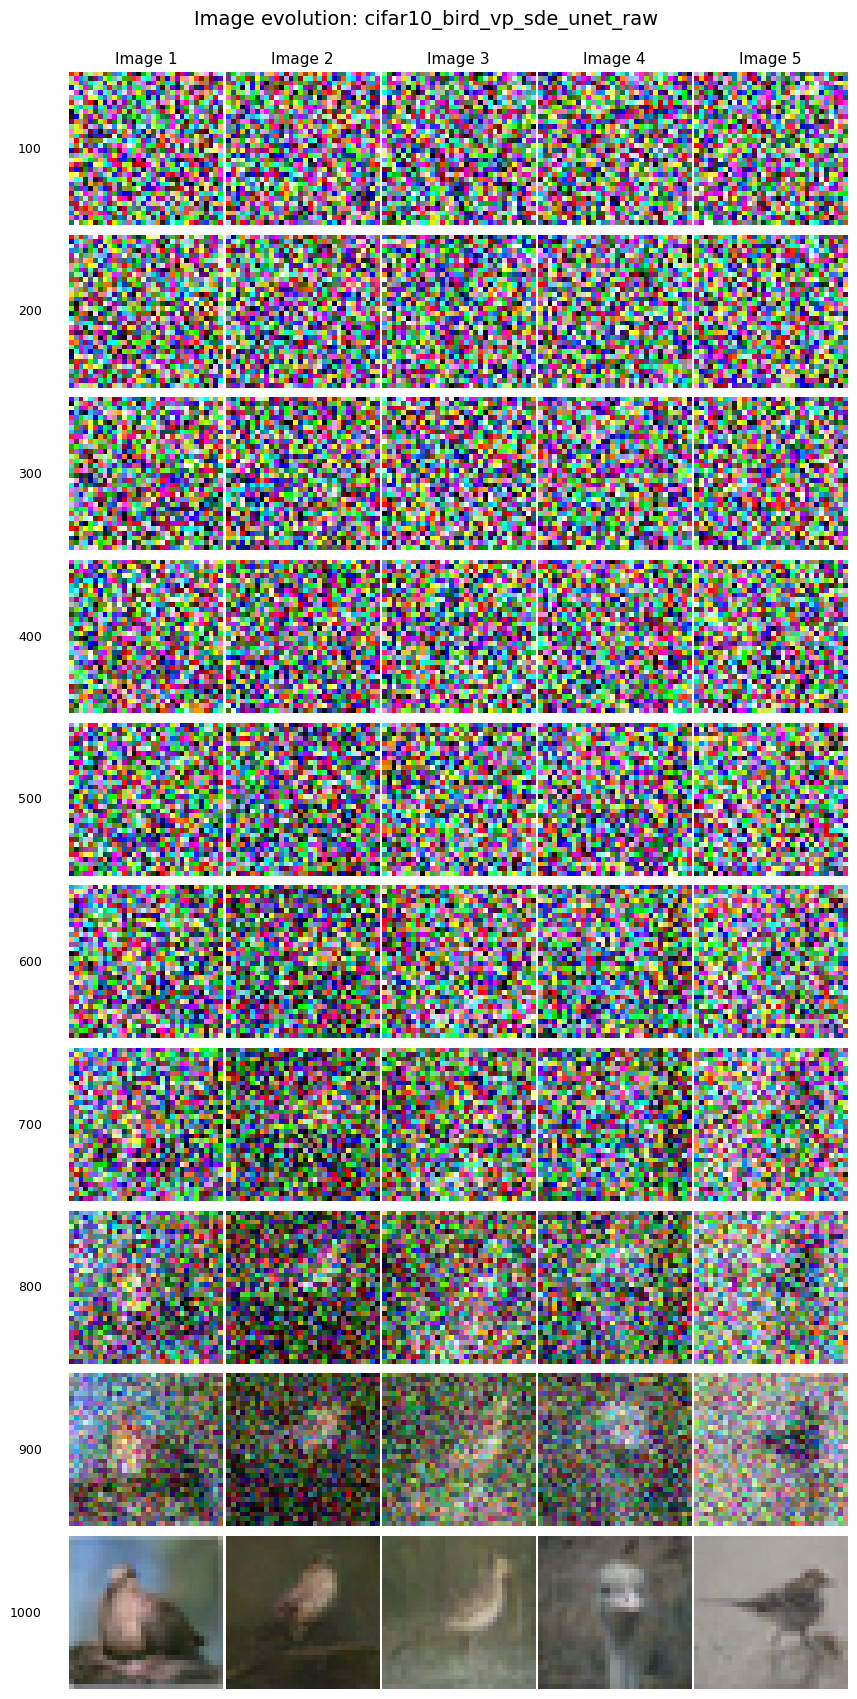

Image evolution saved to: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_ve_raw_sampling_step_gap_analysis/image_evolution/cifar10_bird_vp_sde_unet_raw_evolution_5_images_1000_steps.png
Loaded raw VE-SDE NCSN++: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth
VE raw weight key: ncsnpp

Model: cifar10_bird_ve_sde_ncsnpp_raw
Sampling steps: 100
FID samples: 5000
NN samples: 1000
Corrector steps: 0


VE sampler, 100 steps:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 128/5000 samples


VE sampler, 100 steps:   0%|          | 0/100 [00:00<?, ?it/s]

Generated 256/5000 samples


...

VE sampler, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 4992/5000 samples


VE sampler, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 5000/5000 samples
Computing FID against train...
Computing FID against test...
Computing nearest neighbors against train...
Computing nearest neighbors against test...
Result row:
{
  "model_name": "cifar10_bird_ve_sde_ncsnpp_raw",
  "sampler_kind": "ve",
  "num_steps": 1000,
  "fid_train": 31.543161392211914,
  "fid_gap": 19.828004837036133,
  "train_nn_mean_mse": 0.10474178194999695,
  "nn_gap_mean_mse": 0.0009777098894119263
}
Creating image-evolution figure for cifar10_bird_ve_sde_ncsnpp_raw...


VE evolution, 1000 steps:   0%|          | 0/1000 [00:00<?, ?it/s]

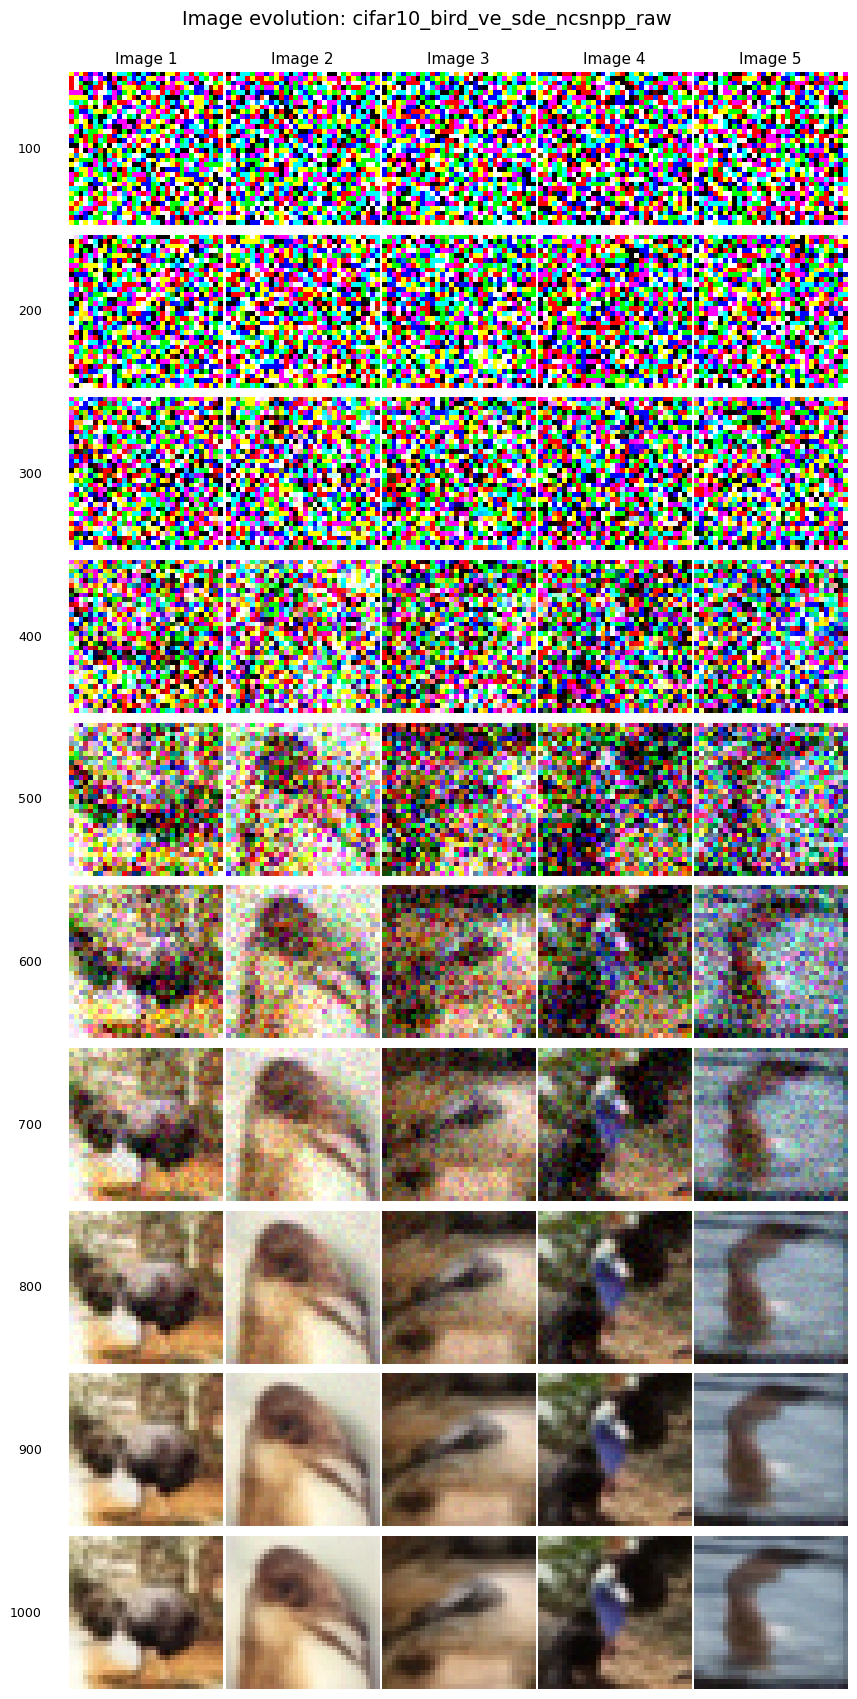

Image evolution saved to: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_ve_raw_sampling_step_gap_analysis/image_evolution/cifar10_bird_ve_sde_ncsnpp_raw_evolution_5_images_1000_steps.png


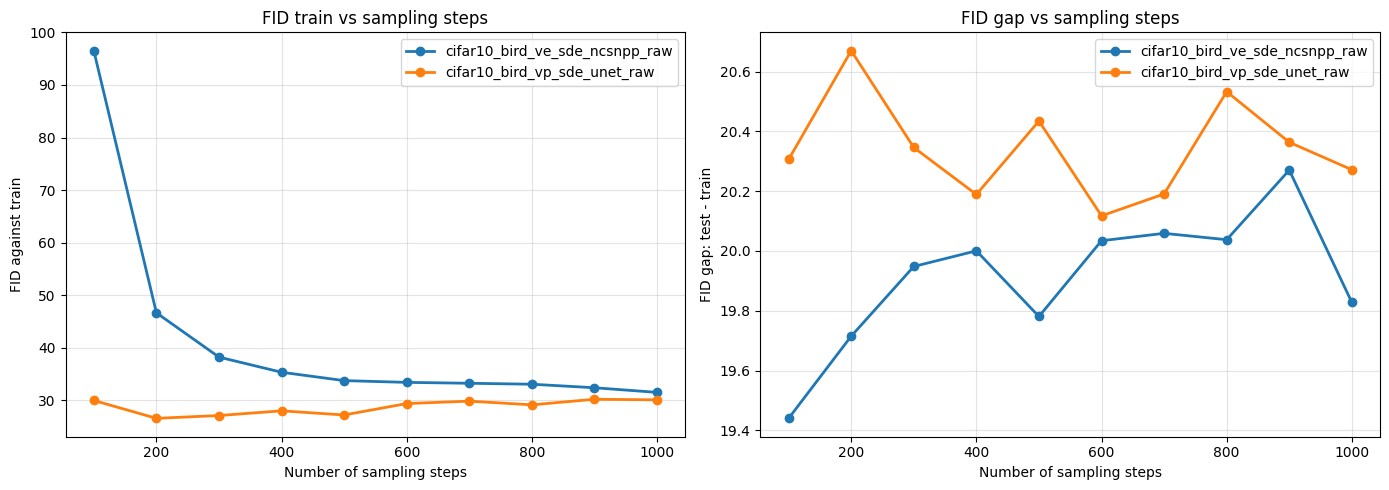

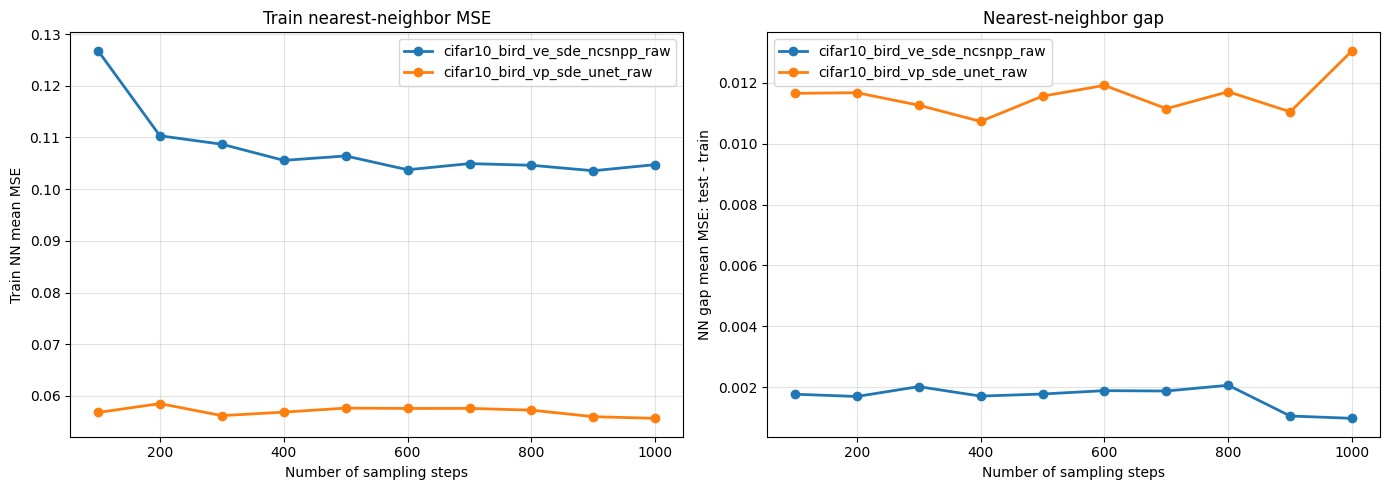


Finished.
Results CSV: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_ve_raw_sampling_step_gap_analysis/bird_vp_ve_raw_sampling_step_results.csv
Results JSON: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_ve_raw_sampling_step_gap_analysis/bird_vp_ve_raw_sampling_step_results.json
Plots folder: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_ve_raw_sampling_step_gap_analysis


In [ ]:
# Evaluation loop

@torch.no_grad()
def evaluate_one_setting(model, model_name, sampler_kind, num_steps, train_images_for_fid, test_images_for_fid, train_images_for_nn, test_images_for_nn,
):
    print("\n" + "= " * 80)
    print(f"Model: {model_name}")
    print(f"Sampling steps: {num_steps}")
    print(f"FID samples: {NUM_FID_SAMPLES_PER_SETTING}")
    print(f"NN samples: {NUM_NN_SAMPLES_PER_SETTING}")
    print(f"Corrector steps: {CORRECTOR_STEPS}")
    print("= " * 80)

    generated_images = generate_samples_in_batches(model=model, sampler_kind=sampler_kind, total_samples=NUM_FID_SAMPLES_PER_SETTING, num_steps=num_steps)

    if SAVE_FID_SAMPLE_GRIDS:
        grid_path = os.path.join(OUTPUT_DIR, "sample_grids", f"{model_name}_{num_steps}_steps.png")
        save_tensor_images_as_grid(generated_images[:100], grid_path, nrow=10)

        print("Computing FID against train...")
        fid_train = compute_fid_against_reference(generated_images=generated_images, reference_images=train_images_for_fid, reference_max_images=FID_REAL_MAX_TRAIN)

        print("Computing FID against test...")
        fid_test = compute_fid_against_reference(generated_images=generated_images, reference_images=test_images_for_fid, reference_max_images=FID_REAL_MAX_TEST)

        nn_generated_images = generated_images[:NUM_NN_SAMPLES_PER_SETTING]

        print("Computing nearest neighbors against train...")
        train_nn_distances = nearest_neighbor_pixel_mse_distances(query_images=nn_generated_images, reference_images=train_images_for_nn)
        train_nn = summarize_distances(train_nn_distances)

        print("Computing nearest neighbors against test...")
        test_nn_distances = nearest_neighbor_pixel_mse_distances(query_images=nn_generated_images, reference_images=test_images_for_nn)
        test_nn = summarize_distances(test_nn_distances)

        row = {
        "model_name": model_name,
        "sampler_kind": sampler_kind,
        "num_steps": int(num_steps),
        "fid_train": float(fid_train),
        "fid_gap": float(fid_test - fid_train),
        "train_nn_mean_mse": train_nn["mean"],
        "nn_gap_mean_mse": float(test_nn["mean"] - train_nn["mean"]),
        }

        print("Result row:")
        print(json.dumps(row, indent=2))

    return row


def main():
    print("Using device:", device)
    maybe_mount_drive()
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    install_dependencies_if_needed()
    ensure_score_sde_repo()

    train_loader, test_loader = build_cifar10_bird_loaders()

    print("Collecting real images for FID and nearest-neighbor metrics...")
    train_images_all = collect_images_from_loader(train_loader, max_images=None)
    test_images_all = collect_images_from_loader(test_loader, max_images=None)

    train_images_for_fid = (
    train_images_all[:FID_REAL_MAX_TRAIN]
    if FID_REAL_MAX_TRAIN is not None
    else train_images_all
    )
    test_images_for_fid = (
    test_images_all[:FID_REAL_MAX_TEST]
    if FID_REAL_MAX_TEST is not None
    else test_images_all
    )
    train_images_for_nn = (
    train_images_all[:NN_REFERENCE_MAX_TRAIN]
    if NN_REFERENCE_MAX_TRAIN is not None
    else train_images_all
    )
    test_images_for_nn = (
    test_images_all[:NN_REFERENCE_MAX_TEST]
    if NN_REFERENCE_MAX_TEST is not None
    else test_images_all
    )

    print("FID train reference images:", train_images_for_fid.shape[0])
    print("FID test reference images:", test_images_for_fid.shape[0])
    print("NN train reference images:", train_images_for_nn.shape[0])
    print("NN test reference images:", test_images_for_nn.shape[0])

    rows = load_existing_results()
    done = {
    (str(row["model_name"]), int(row["num_steps"]))
    for row in rows
    if "model_name" in row and "num_steps" in row
    }

    model_specs = [
    {'model_name': 'cifar10_bird_vp_sde_unet_raw', 'sampler_kind': 'vp', 'loader': lambda: load_vp_unet_model(VP_UNET_CHECKPOINT, weight_key=VP_WEIGHT_KEY), 'seed_offset': 10000},
    {'model_name': 'cifar10_bird_ve_sde_ncsnpp_raw', 'sampler_kind': 've', 'loader': lambda: load_ve_ncsnpp_model(VE_NCSNPP_CHECKPOINT, weight_key=VE_WEIGHT_KEY), 'seed_offset': 20000},
    ]

    for spec in model_specs:
        model_name=spec["model_name"]
        sampler_kind = spec["sampler_kind"]

        remaining_steps = [
        step for step in STEPS_LIST
        if (model_name, int(step)) not in done
        ]

        model=spec["loader"]()

    if not remaining_steps:
        print(f"All requested steps already evaluated for {model_name}.")
    else:
        for num_steps in remaining_steps:
            set_seed(BASE_SEED + spec["seed_offset"] + int(num_steps))

            row = evaluate_one_setting(model=model, model_name=model_name, sampler_kind=sampler_kind,
                num_steps=num_steps, train_images_for_fid=train_images_for_fid,
                test_images_for_fid=test_images_for_fid, train_images_for_nn=train_images_for_nn,
                test_images_for_nn=test_images_for_nn)

            rows.append(row)
            save_results(rows)

        if RUN_IMAGE_EVOLUTION:
            print(f"Creating image-evolution figure for {model_name}...")
            set_seed(BASE_SEED + spec["seed_offset"] + EVOLUTION_SEED_OFFSET)
            snapshots = collect_image_evolution(model=model, sampler_kind=sampler_kind)
            evolution_path = save_and_show_image_evolution(snapshots=snapshots, model_name=model_name)
            print("Image evolution saved to:", evolution_path)

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

                final_df = save_results(rows)
                plot_all_results(final_df)

                print("\nFinished.")
                print("Results CSV:", results_csv_path())
                print("Results JSON:", results_json_path())
                print("Plots folder:", OUTPUT_DIR)


if __name__ == "__main__":
    main()
